# 🌡️ Temperature Forecasting — BiLSTM Encoder-Decoder
### Weather Forecasting MLOps | Azamgarh ERA5 Dataset
---
**Objective:** Forecast temperature for the next **N hours** (default: 5) using past 24h of ERA5 data.  
**Architecture:** Encoder-Decoder BiLSTM — encoder reads 24h input, decoder generates N-step forecast.  
**Strategy:** Optuna tunes hyperparameters first, then train once with best params.

| Section | Description |
|---------|-------------|
| 1 | Environment Setup & Imports |
| 2 | MLflow Setup |
| 3 | Data Loading & Inspection |
| 4 | Preprocessing & Sequence Generation |
| 5 | Hyperparameter Tuning — Optuna |
| 6 | Model Architecture (Best Params) |
| 7 | Training with Callbacks |
| 8 | Evaluation & Visualization |
| 9 | Save Model & Log to MLflow |
| 10 | Inference Function |

## 1. Environment Setup & Imports

In [53]:
import os, json, warnings
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"]  = "3"
os.environ["TF_DETERMINISTIC_OPS"]  = "1"
os.environ["PYTHONHASHSEED"]         = "42"

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import joblib
import glob

import tensorflow as tf
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import (
    Input, LSTM, Dense, Dropout, Bidirectional,
    RepeatVector, TimeDistributed, Reshape,
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.initializers import GlorotUniform, Orthogonal
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import mlflow
import mlflow.keras
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Reproducibility ──
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

plt.rcParams.update({
    "figure.dpi"       : 120,
    "figure.facecolor" : "white",
    "axes.spines.top"  : False,
    "axes.spines.right": False,
})
sns.set_palette("husl")

# ── Paths ──
DATA_PATH = sorted(glob.glob("../artifact/*/data_transformation/weather_final.csv"))[-1]
MODEL_DIR  = "../models/lstm"
MODEL_IMAGES_DIR  = "../models/lstm/images"
SCALER_DIR = "../models/scalers"
os.makedirs(MODEL_DIR,  exist_ok=True)
os.makedirs(MODEL_IMAGES_DIR,  exist_ok=True)
os.makedirs(SCALER_DIR, exist_ok=True)

# ── Fixed hyperparameters ──
LOOKBACK   = 24
FORECAST_N = 5
BATCH_SIZE = 32
EPOCHS     = 100
TARGET_COL = "temperature"
TARGET_IDX = 0

# FEATURES = [
#     "temperature",
#     "surface_pressure",
#     "total_cloud_cover",
#     "precipitation",
#     "humidity",
#     "wind_speed",
#     "month",
# ]
FEATURES = [
    "temperature",        # index 0 — TARGET (always first)
    "temp_lag_1",         # 1h ago  — autocorr ~0.99
    "temp_lag_24",        # same hour yesterday — autocorr ~0.85
    "temp_rolling_6",     # 6h smooth trend
    "humidity",           # strong inverse corr with temp
    "surface_pressure",   # pressure systems drive temp change
    "total_cloud_cover",  # clouds moderate temperature swings
    "wind_speed",         # advection effect
    "hour_sin",           # sin(2π × hour / 24)
    "hour_cos",           # cos(2π × hour / 24)
    "month_sin",          # sin(2π × month / 12)
    "month_cos",          # cos(2π × month / 12)
]
N_FEATURES = len(FEATURES)

print(f"TensorFlow  : {tf.__version__}")
print(f"Data path   : {DATA_PATH}")
print(f"Lookback    : {LOOKBACK}h | Forecast: {FORECAST_N}h | Features: {N_FEATURES}")

TensorFlow  : 2.19.0
Data path   : ../artifact\10_10_2026_14_46_58\data_transformation\weather_final.csv
Lookback    : 24h | Forecast: 5h | Features: 12


## 2. MLflow Setup

In [54]:
# ── MLflow configuration ──
MLFLOW_TRACKING_URI = os.getenv("MLFLOW_TRACKING_URI") 
EXPERIMENT_NAME     = "weather_temperature_lstm"

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment(EXPERIMENT_NAME)

print(f"MLflow tracking URI : {MLFLOW_TRACKING_URI}")
print(f"Experiment          : {EXPERIMENT_NAME}")
print(f"UI                  : {MLFLOW_TRACKING_URI}/#/experiments")

MLflow tracking URI : https://dagshub.com/Sharif-Abusad/weather-forecasting-system-mlops.mlflow
Experiment          : weather_temperature_lstm
UI                  : https://dagshub.com/Sharif-Abusad/weather-forecasting-system-mlops.mlflow/#/experiments


## 3. Data Loading & Inspection

In [55]:
df = pd.read_csv(DATA_PATH, parse_dates=["valid_time"])
df = df.sort_values("valid_time").reset_index(drop=True)

print(f"Shape      : {df.shape}")
print(f"Date range : {df['valid_time'].min()} → {df['valid_time'].max()}")
print(f"Missing    : {df.isnull().sum().sum()}")
print(f"\nTemperature stats:")
print(df[TARGET_COL].describe().round(2))

Shape      : (43800, 22)
Date range : 2021-01-02 05:30:00 → 2026-01-01 04:30:00
Missing    : 0

Temperature stats:
count    43800.00
mean        25.84
std          7.42
min          5.30
25%         20.57
50%         27.46
75%         30.92
max         44.94
Name: temperature, dtype: float64


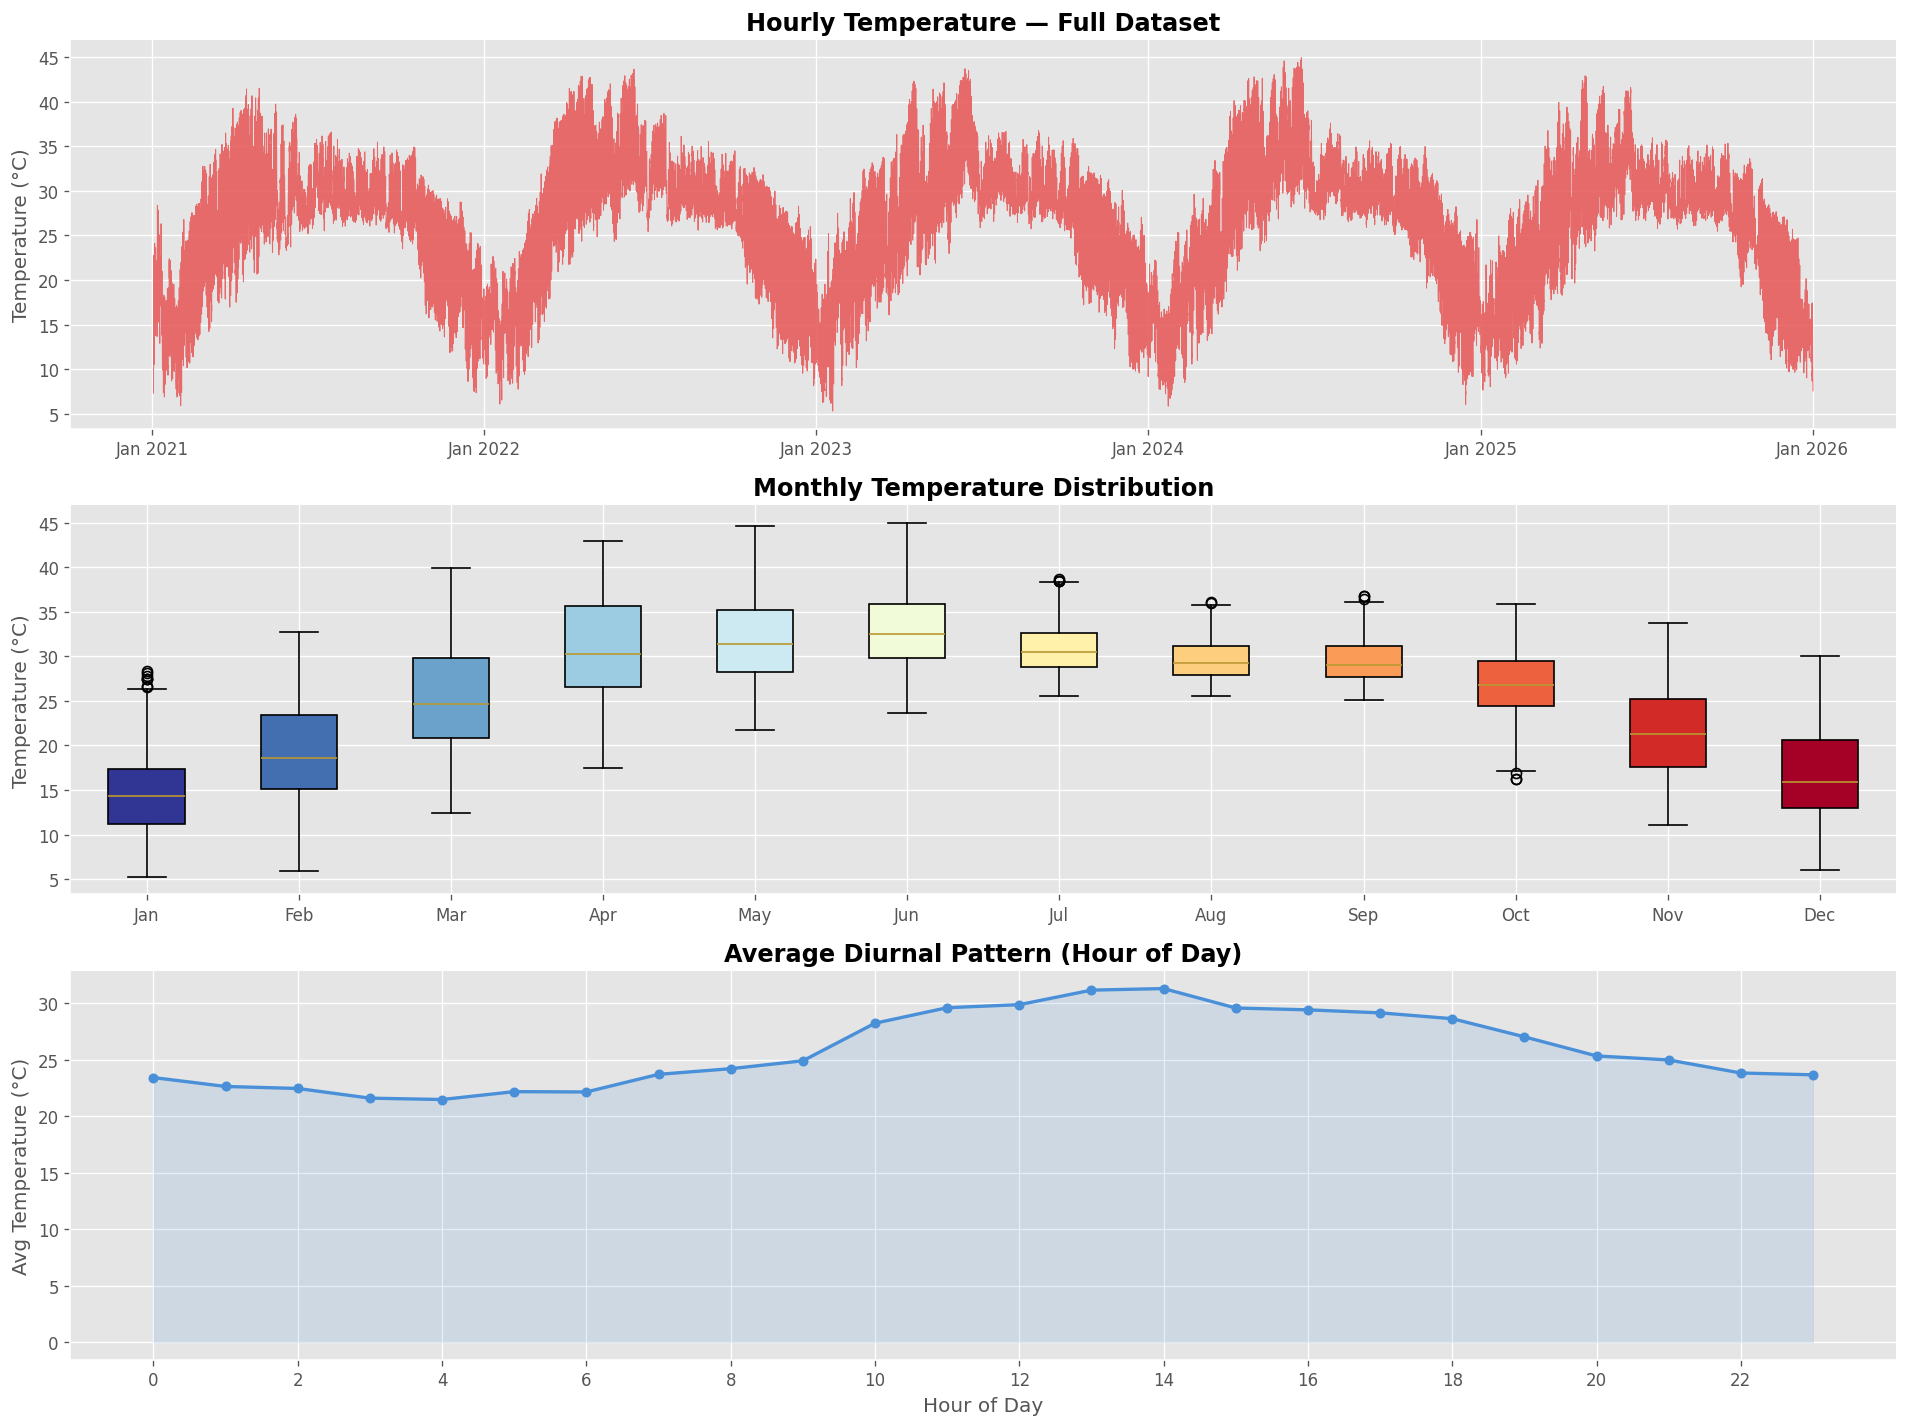

In [56]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# Full time series
axes[0].plot(df["valid_time"], df[TARGET_COL], lw=0.6, color="#E85D5D", alpha=0.9)
axes[0].set_title("Hourly Temperature — Full Dataset", fontweight="bold")
axes[0].set_ylabel("Temperature (°C)")
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

# Monthly boxplot
months = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
monthly_data = [df[df["valid_time"].dt.month == m][TARGET_COL].values for m in range(1,13)]
bp = axes[1].boxplot(monthly_data, patch_artist=True, labels=months)
colors = plt.cm.RdYlBu_r(np.linspace(0, 1, 12))
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
axes[1].set_title("Monthly Temperature Distribution", fontweight="bold")
axes[1].set_ylabel("Temperature (°C)")

# Diurnal pattern
df["hour_of_day"] = df["valid_time"].dt.hour
hourly_avg = df.groupby("hour_of_day")[TARGET_COL].mean()
axes[2].plot(hourly_avg.index, hourly_avg.values, "o-", color="#4A90D9", lw=2, ms=5)
axes[2].fill_between(hourly_avg.index, hourly_avg.values, alpha=0.15, color="#4A90D9")
axes[2].set_title("Average Diurnal Pattern (Hour of Day)", fontweight="bold")
axes[2].set_ylabel("Avg Temperature (°C)")
axes[2].set_xlabel("Hour of Day")
axes[2].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.savefig(f"{MODEL_IMAGES_DIR}/eda_temperature.png", bbox_inches="tight")
plt.show()

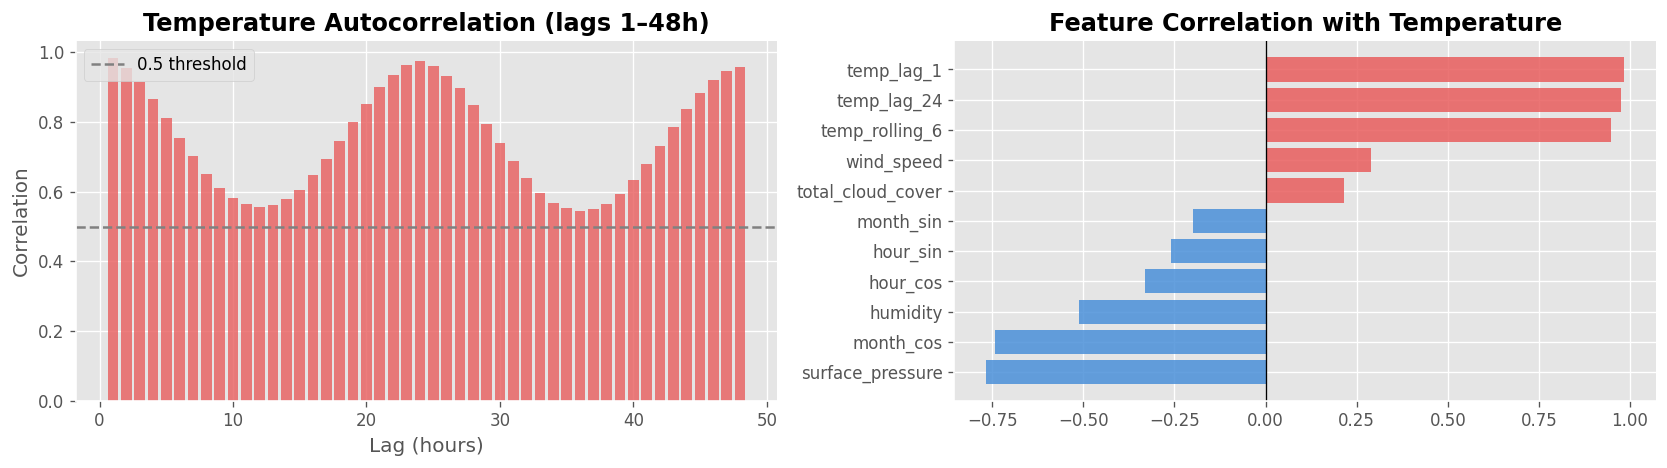

Lag-1 autocorrelation  : 0.9838
Lag-24 autocorrelation : 0.9761
→ High lag-1 & lag-24 confirm LSTM will work well here.


In [57]:
# Autocorrelation
lags = range(1, 49)
corr = [df[TARGET_COL].autocorr(lag=l) for l in lags]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(lags, corr, color=["#E85D5D" if c > 0 else "#4A90D9" for c in corr], alpha=0.8)
axes[0].axhline(0.5, color="gray", linestyle="--", label="0.5 threshold")
axes[0].set_title("Temperature Autocorrelation (lags 1–48h)", fontweight="bold")
axes[0].set_xlabel("Lag (hours)"); axes[0].set_ylabel("Correlation")
axes[0].legend()

feat_corr = df[FEATURES].corr()[TARGET_COL].drop(TARGET_COL).sort_values()
axes[1].barh(feat_corr.index, feat_corr.values,
             color=["#E85D5D" if v > 0 else "#4A90D9" for v in feat_corr.values], alpha=0.85)
axes[1].axvline(0, color="black", lw=0.8)
axes[1].set_title("Feature Correlation with Temperature", fontweight="bold")

plt.tight_layout()
plt.savefig(f"{MODEL_IMAGES_DIR}/autocorrelation.png", bbox_inches="tight")
plt.show()

print(f"Lag-1 autocorrelation  : {df[TARGET_COL].autocorr(lag=1):.4f}")
print(f"Lag-24 autocorrelation : {df[TARGET_COL].autocorr(lag=24):.4f}")
print("→ High lag-1 & lag-24 confirm LSTM will work well here.")

## 4. Preprocessing & Sequence Generation

In [58]:
df_model = df[["valid_time"] + FEATURES].dropna().reset_index(drop=True)
print(f"Model rows: {len(df_model):,}")

scaler = MinMaxScaler(feature_range=(0, 1))
scaled = scaler.fit_transform(df_model[FEATURES].values).astype(np.float32)

scaler_path = f"{SCALER_DIR}/lstm_temp_scaler.pkl"
joblib.dump(scaler, scaler_path)
print(f"Scaler saved → {scaler_path}")

Model rows: 43,800
Scaler saved → ../models/scalers/lstm_temp_scaler.pkl


In [59]:
def create_sequences(data, lookback, forecast_n, target_idx=0):
    X, y = [], []
    for i in range(len(data) - lookback - forecast_n + 1):
        X.append(data[i: i + lookback])
        y.append(data[i + lookback: i + lookback + forecast_n, target_idx])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

X, y = create_sequences(scaled, LOOKBACK, FORECAST_N, TARGET_IDX)
print(f"X: {X.shape} | y: {y.shape}")

# 70/15/15 time-based split
n         = len(X)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

X_train, y_train = X[:train_end],        y[:train_end]
X_val,   y_val   = X[train_end:val_end], y[train_end:val_end]
X_test,  y_test  = X[val_end:],          y[val_end:]

print(f"Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}")

X: (43772, 24, 12) | y: (43772, 5)
Train: 30,640 | Val: 6,566 | Test: 6,566


In [60]:
def inverse_temp(scaled_vals):
    dummy = np.zeros((len(scaled_vals), N_FEATURES))
    dummy[:, TARGET_IDX] = scaled_vals
    return scaler.inverse_transform(dummy)[:, TARGET_IDX]

## 5. Hyperparameter Tuning — Optuna
Find best params first. Run once, then copy to `params.yaml`.

In [62]:
def build_model(lstm_units, dropout_rate, learning_rate, lookback, forecast_n, n_features):
    kernel_init    = GlorotUniform(seed=SEED)
    recurrent_init = Orthogonal(gain=1.0, seed=SEED)

    inputs = Input(shape=(lookback, n_features))
    x = Bidirectional(
        LSTM(lstm_units, return_sequences=True,
             kernel_initializer=kernel_init,
             recurrent_initializer=recurrent_init,
             dropout=dropout_rate * 0.5)
    )(inputs)
    x = Dropout(dropout_rate)(x)
    x = LSTM(lstm_units // 2, return_sequences=False,
             kernel_initializer=kernel_init,
             recurrent_initializer=recurrent_init)(x)
    x = RepeatVector(forecast_n)(x)
    x = LSTM(lstm_units // 2, return_sequences=True,
             kernel_initializer=kernel_init,
             recurrent_initializer=recurrent_init)(x)
    x = Dropout(dropout_rate)(x)
    x = TimeDistributed(Dense(32, activation="relu"))(x)
    x = TimeDistributed(Dense(1))(x)
    x = Reshape((forecast_n,))(x)

    model = Model(inputs, x)
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="huber",
        metrics=["mae"]
    )
    return model


def objective(trial):
    lstm_units = trial.suggest_categorical(
        "lstm_units", [32, 64]
    )

    dropout_rate = trial.suggest_float(
        "dropout_rate", 0.2, 0.5
    )

    learning_rate = trial.suggest_float(
        "learning_rate", 1e-4, 3e-3, log=True
    )

    batch_size = trial.suggest_categorical(
        "batch_size", [32, 64]
    )

    with mlflow.start_run(
        run_name=f"lstm_trial_{trial.number}",
        nested=True
    ):
        mlflow.set_tags({
            "stage": "hyperparameter_tuning",
            "model_type": "BiLSTM",
            "tuner": "Optuna",
            "trial_number": str(trial.number),
        })

        mlflow.log_params({
            "lstm_units": lstm_units,
            "dropout_rate": dropout_rate,
            "learning_rate": learning_rate,
            "batch_size": batch_size,
        })

        model = build_model(
            lstm_units,
            dropout_rate,
            learning_rate,
            LOOKBACK,
            FORECAST_N,
            N_FEATURES
        )

        cb = [
            EarlyStopping(
                monitor="val_loss",
                patience=5,
                restore_best_weights=True
            ),
            optuna.integration.TFKerasPruningCallback(
                trial, "val_loss"
            ),
        ]

        history = model.fit(
            X_train,
            y_train,
            validation_data=(X_val, y_val),
            epochs=30,
            batch_size=batch_size,
            callbacks=cb,
            verbose=1,
        )

        best_val_loss = min(history.history["val_loss"])

        mlflow.log_metric("best_val_loss", best_val_loss)

        for epoch, (train_loss, val_loss) in enumerate(
            zip(
                history.history["loss"],
                history.history["val_loss"]
            )
        ):
            mlflow.log_metrics({
                "train_loss": float(train_loss),
                "val_loss": float(val_loss),
            }, step=epoch)

        print(
            f"Trial {trial.number} | "
            f"Best val_loss: {best_val_loss:.6f}"
        )

        return best_val_loss


with mlflow.start_run(run_name="lstm_optuna_tuning") as parent_run:

    study = optuna.create_study(
        direction="minimize",
        study_name="lstm_temp_tuning",
        sampler=optuna.samplers.TPESampler(seed=SEED),
        pruner=optuna.pruners.MedianPruner(
            n_warmup_steps=3
        ),
    )

    study.optimize(
        objective,
        n_trials=20,
        show_progress_bar=True
    )

    BEST_PARAMS = study.best_params

    mlflow.log_params(BEST_PARAMS)
    mlflow.log_metric("best_val_loss", study.best_value)
    mlflow.log_metric("n_trials", len(study.trials))

    optuna_run_id = parent_run.info.run_id

print(f"Parent MLflow run ID: {optuna_run_id}")
print(f"Best validation loss: {study.best_value:.6f}")
print("Best parameters:")

for k, v in BEST_PARAMS.items():
    print(f"  {k:<18}: {v}")

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch 1/30
958/958 ━━━━━━━━━━━━━━━━━━━━ 27s 21ms/step - loss: 0.0058 - mae: 0.0781 - val_loss: 0.0041 - val_mae: 0.0784
Epoch 2/30
958/958 ━━━━━━━━━━━━━━━━━━━━ 22s 23ms/step - loss: 0.0018 - mae: 0.0467 - val_loss: 0.0047 - val_mae: 0.0855
Epoch 3/30
958/958 ━━━━━━━━━━━━━━━━━━━━ 22s 23ms/step - loss: 0.0013 - mae: 0.0395 - val_loss: 0.0041 - val_mae: 0.0782
Epoch 4/30
958/958 ━━━━━━━━━━━━━━━━━━━━ 22s 23ms/step - loss: 0.0011 - mae: 0.0367 - val_loss: 0.0048 - val_mae: 0.0880
Epoch 5/30
958/958 ━━━━━━━━━━━━━━━━━━━━ 22s 23ms/step - loss: 9.9502e-04 - mae: 0.0344 - val_loss: 0.0065 - val_mae: 0.1022
Epoch 6/30
958/958 ━━━━━━━━━━━━━━━━━━━━ 23s 24ms/step - loss: 9.0410e-04 - mae: 0.0328 - val_loss: 0.0075 - val_mae: 0.1112
Epoch 7/30
958/958 ━━━━━━━━━━━━━━━━━━━━ 23s 24ms/step - loss: 8.4889e-04 - mae: 0.0318 - val_loss: 0.0067 - val_mae: 0.1052
Epoch 8/30
958/958 ━━━━━━━━━━━━━━━━━━━━ 23s 24ms/step - loss: 7.8987e-04 - mae: 0.0306 - val_loss: 0.0081 - val_mae: 0.1165
Trial 0 | Best val_loss:

Best trial: 0. Best value: 0.00411325:   5%|▌         | 1/20 [03:18<1:02:44, 198.12s/it]

Epoch 1/30
479/479 ━━━━━━━━━━━━━━━━━━━━ 21s 31ms/step - loss: 0.0072 - mae: 0.0855 - val_loss: 0.0043 - val_mae: 0.0781
Epoch 2/30
479/479 ━━━━━━━━━━━━━━━━━━━━ 17s 35ms/step - loss: 0.0018 - mae: 0.0471 - val_loss: 0.0034 - val_mae: 0.0679
Epoch 3/30
479/479 ━━━━━━━━━━━━━━━━━━━━ 16s 34ms/step - loss: 0.0013 - mae: 0.0390 - val_loss: 0.0050 - val_mae: 0.0887
Epoch 4/30
479/479 ━━━━━━━━━━━━━━━━━━━━ 16s 34ms/step - loss: 0.0011 - mae: 0.0359 - val_loss: 0.0055 - val_mae: 0.0935
Epoch 5/30
479/479 ━━━━━━━━━━━━━━━━━━━━ 17s 35ms/step - loss: 9.7008e-04 - mae: 0.0339 - val_loss: 0.0068 - val_mae: 0.1055
Epoch 6/30
479/479 ━━━━━━━━━━━━━━━━━━━━ 16s 34ms/step - loss: 8.6408e-04 - mae: 0.0320 - val_loss: 0.0057 - val_mae: 0.0925
Epoch 7/30
479/479 ━━━━━━━━━━━━━━━━━━━━ 16s 34ms/step - loss: 8.2836e-04 - mae: 0.0313 - val_loss: 0.0061 - val_mae: 0.0970
Trial 1 | Best val_loss: 0.003375
🏃 View run lstm_trial_1 at: https://dagshub.com/Sharif-Abusad/weather-forecasting-system-mlops.mlflow/#/experiment

Best trial: 1. Best value: 0.00337519:  10%|█         | 2/20 [05:30<47:47, 159.31s/it]  

...

Epoch 1/30
479/479 ━━━━━━━━━━━━━━━━━━━━ 26s 41ms/step - loss: 0.0056 - mae: 0.0733 - val_loss: 0.0020 - val_mae: 0.0540
Epoch 2/30
479/479 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - loss: 0.0014 - mae: 0.0404 - val_loss: 0.0015 - val_mae: 0.0468
Epoch 3/30
479/479 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - loss: 0.0010 - mae: 0.0349 - val_loss: 0.0024 - val_mae: 0.0617
Epoch 4/30
479/479 ━━━━━━━━━━━━━━━━━━━━ 21s 43ms/step - loss: 8.8510e-04 - mae: 0.0324 - val_loss: 0.0026 - val_mae: 0.0632
Epoch 5/30
479/479 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - loss: 7.6548e-04 - mae: 0.0302 - val_loss: 0.0031 - val_mae: 0.0695
Epoch 6/30
479/479 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - loss: 7.3837e-04 - mae: 0.0296 - val_loss: 0.0016 - val_mae: 0.0482
Epoch 7/30
479/479 ━━━━━━━━━━━━━━━━━━━━ 20s 43ms/step - loss: 7.1532e-04 - mae: 0.0292 - val_loss: 0.0036 - val_mae: 0.0751
Trial 18 | Best val_loss: 0.001523
🏃 View run lstm_trial_18 at: https://dagshub.com/Sharif-Abusad/weather-forecasting-system-mlops.mlflow/#/expe

Best trial: 13. Best value: 0.000578054:  95%|█████████▌| 19/20 [50:18<02:51, 171.34s/it]

Epoch 1/30
958/958 ━━━━━━━━━━━━━━━━━━━━ 34s 29ms/step - loss: 0.0038 - mae: 0.0614 - val_loss: 0.0014 - val_mae: 0.0434
Epoch 2/30
958/958 ━━━━━━━━━━━━━━━━━━━━ 28s 29ms/step - loss: 0.0012 - mae: 0.0379 - val_loss: 0.0014 - val_mae: 0.0441
Epoch 3/30
958/958 ━━━━━━━━━━━━━━━━━━━━ 28s 29ms/step - loss: 9.1601e-04 - mae: 0.0331 - val_loss: 0.0016 - val_mae: 0.0480
Epoch 4/30
958/958 ━━━━━━━━━━━━━━━━━━━━ 28s 29ms/step - loss: 7.6531e-04 - mae: 0.0302 - val_loss: 0.0025 - val_mae: 0.0629
Epoch 5/30
958/958 ━━━━━━━━━━━━━━━━━━━━ 28s 30ms/step - loss: 7.0909e-04 - mae: 0.0290 - val_loss: 0.0018 - val_mae: 0.0501
Epoch 6/30
958/958 ━━━━━━━━━━━━━━━━━━━━ 28s 29ms/step - loss: 6.5164e-04 - mae: 0.0278 - val_loss: 0.0025 - val_mae: 0.0621
Trial 19 | Best val_loss: 0.001413
🏃 View run lstm_trial_19 at: https://dagshub.com/Sharif-Abusad/weather-forecasting-system-mlops.mlflow/#/experiments/1/runs/e19c227453b54bd8a720d7bdf8c4ea9c
🧪 View experiment at: https://dagshub.com/Sharif-Abusad/weather-forecast

Best trial: 13. Best value: 0.000578054: 100%|██████████| 20/20 [53:29<00:00, 160.47s/it]


🏃 View run lstm_optuna_tuning at: https://dagshub.com/Sharif-Abusad/weather-forecasting-system-mlops.mlflow/#/experiments/1/runs/c431602b56864fc6ba0b43db584cdda6
🧪 View experiment at: https://dagshub.com/Sharif-Abusad/weather-forecasting-system-mlops.mlflow/#/experiments/1
Parent MLflow run ID: c431602b56864fc6ba0b43db584cdda6
Best validation loss: 0.000578
Best parameters:
  lstm_units        : 64
  dropout_rate      : 0.21596778466458033
  learning_rate     : 0.002497202586031813
  batch_size        : 32


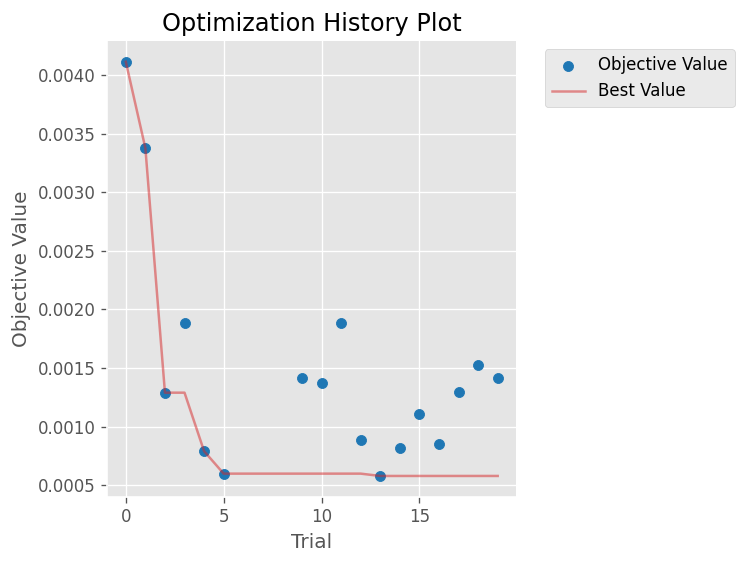

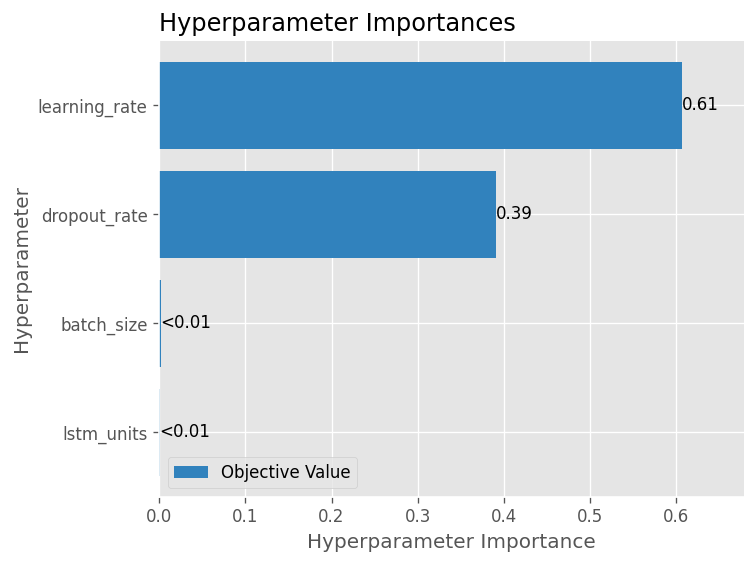

In [63]:
# ── Optuna visualizations ──
try:
    from optuna.visualization.matplotlib import (
        plot_optimization_history,
        plot_param_importances,
    )

    # Optimization history
    plot_optimization_history(study)
    plt.tight_layout()

    optimization_history_path = (
        f"{MODEL_IMAGES_DIR}/optuna_optimization_history.png"
    )

    plt.savefig(
        optimization_history_path,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

    # Parameter importance
    plot_param_importances(study)
    plt.tight_layout()

    param_importance_path = (
        f"{MODEL_IMAGES_DIR}/optuna_param_importance.png"
    )

    plt.savefig(
        param_importance_path,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

except Exception as e:
    print(f"Plot skipped: {e}")

In [64]:
# ── Log best LSTM Optuna trial to MLflow ──
with mlflow.start_run(
    run_name="lstm_optuna_best_trial"
) as optuna_run:

    mlflow.set_tags({
        "stage": "hyperparameter_tuning",
        "model_type": "BiLSTM",
        "tuner": "Optuna",
        "study_name": "lstm_temp_tuning",
        "target": "temperature_forecasting",
    })

    # Best hyperparameters
    mlflow.log_params(study.best_params)

    # Best validation loss
    mlflow.log_metric(
        "best_val_loss",
        study.best_value
    )

    # Number of trials
    mlflow.log_metric(
        "n_trials",
        len(study.trials)
    )

    # Log Optuna visualizations
    try:
        mlflow.log_artifact(
            f"{MODEL_IMAGES_DIR}/optuna_optimization_history.png"
        )

        mlflow.log_artifact(
            f"{MODEL_IMAGES_DIR}/optuna_param_importance.png"
        )

    except Exception as e:
        print(f"Could not log Optuna plots: {e}")

    optuna_run_id = optuna_run.info.run_id

print(f"Optuna run logged → {optuna_run_id}")

print(f"\n{'=' * 50}")
print("  COPY THESE TO params.yaml → lstm section:")
print(f"{'=' * 50}")

for k, v in study.best_params.items():
    print(f"  {k:<22} : {v}")

print(f"{'=' * 50}")

🏃 View run lstm_optuna_best_trial at: https://dagshub.com/Sharif-Abusad/weather-forecasting-system-mlops.mlflow/#/experiments/1/runs/2b8a120826ef492eb9003727a5f703ff
🧪 View experiment at: https://dagshub.com/Sharif-Abusad/weather-forecasting-system-mlops.mlflow/#/experiments/1
Optuna run logged → 2b8a120826ef492eb9003727a5f703ff

  COPY THESE TO params.yaml → lstm section:
  lstm_units             : 64
  dropout_rate           : 0.21596778466458033
  learning_rate          : 0.002497202586031813
  batch_size             : 32


## 6. Model Architecture (Best Params)
Train once using hyperparameters found by Optuna.

In [65]:
LSTM_UNITS    = BEST_PARAMS["lstm_units"]
DROPOUT_RATE  = BEST_PARAMS["dropout_rate"]
LEARNING_RATE = BEST_PARAMS["learning_rate"]
BATCH_SIZE    = BEST_PARAMS["batch_size"]

model = build_model(
    LSTM_UNITS, DROPOUT_RATE, LEARNING_RATE,
    LOOKBACK, FORECAST_N, N_FEATURES
)
model.summary()

print(f"\n── Architecture Summary ──")
print(f"  Input    : ({LOOKBACK}h × {N_FEATURES} features)")
print(f"  BiLSTM   : {LSTM_UNITS} units")
print(f"  Dropout  : {DROPOUT_RATE}")
print(f"  LR       : {LEARNING_RATE}")
print(f"  Output   : {FORECAST_N} temperature values")
print(f"  Params   : {model.count_params():,}")

Model: "functional_61"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_61 (InputLayer)     │ (None, 24, 12)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_61                │ (None, 24, 128)        │        39,424 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_122 (Dropout)           │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_184 (LSTM)                 │ (None, 32)             │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_61 (RepeatVector) │ (None, 5, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_185 (LSTM)                 │ (None, 5, 32)          │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_123 (Dropout)           │ (None, 5, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_122            │ (None, 5, 32)          │         1,056 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_123            │ (None, 5, 1)           │            33 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_61 (Reshape)            │ (None, 5)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 69,441 (271.25 KB)

 Trainable params: 69,441 (271.25 KB)

 Non-trainable params: 0 (0.00 B)


── Architecture Summary ──
  Input    : (24h × 12 features)
  BiLSTM   : 64 units
  Dropout  : 0.21596778466458033
  LR       : 0.002497202586031813
  Output   : 5 temperature values
  Params   : 69,441


## 7. Training with Callbacks

In [66]:
ckpt_path = f"{MODEL_DIR}/best_lstm.keras"

callbacks = [
    EarlyStopping(
        monitor="val_loss", patience=10,
        restore_best_weights=True, verbose=1, min_delta=1e-4,
    ),
    ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=7,
        min_lr=1e-6, verbose=1, cooldown=3,
    ),
    ModelCheckpoint(
        filepath=ckpt_path, monitor="val_loss",
        save_best_only=True, verbose=0,
    ),
]

print(f"Training on {len(X_train):,} samples...")
history = model.fit(
    X_train, y_train,
    validation_data = (X_val, y_val),
    epochs          = EPOCHS,
    batch_size      = BATCH_SIZE,
    callbacks       = callbacks,
    shuffle         = False,
    verbose         = 1,
)

best_epoch    = int(np.argmin(history.history["val_loss"])) + 1
best_val_loss = float(np.min(history.history["val_loss"]))
print(f"\nBest epoch: {best_epoch} | val_loss: {best_val_loss:.6f}")

Training on 30,640 samples...
Epoch 1/100
958/958 ━━━━━━━━━━━━━━━━━━━━ 42s 34ms/step - loss: 0.0037 - mae: 0.0661 - val_loss: 0.0270 - val_mae: 0.1783 - learning_rate: 0.0025
Epoch 2/100
958/958 ━━━━━━━━━━━━━━━━━━━━ 34s 36ms/step - loss: 0.0033 - mae: 0.0626 - val_loss: 0.0323 - val_mae: 0.2029 - learning_rate: 0.0025
Epoch 3/100
958/958 ━━━━━━━━━━━━━━━━━━━━ 34s 36ms/step - loss: 0.0032 - mae: 0.0611 - val_loss: 0.0326 - val_mae: 0.2059 - learning_rate: 0.0025
Epoch 4/100
958/958 ━━━━━━━━━━━━━━━━━━━━ 34s 35ms/step - loss: 0.0042 - mae: 0.0708 - val_loss: 0.0274 - val_mae: 0.1830 - learning_rate: 0.0025
Epoch 5/100
958/958 ━━━━━━━━━━━━━━━━━━━━ 34s 36ms/step - loss: 0.0035 - mae: 0.0635 - val_loss: 0.0272 - val_mae: 0.1869 - learning_rate: 0.0025
Epoch 6/100
958/958 ━━━━━━━━━━━━━━━━━━━━ 34s 35ms/step - loss: 0.0035 - mae: 0.0642 - val_loss: 0.0271 - val_mae: 0.1860 - learning_rate: 0.0025
Epoch 7/100
958/958 ━━━━━━━━━━━━━━━━━━━━ 34s 36ms/step - loss: 0.0032 - mae: 0.0614 - val_loss: 0.02

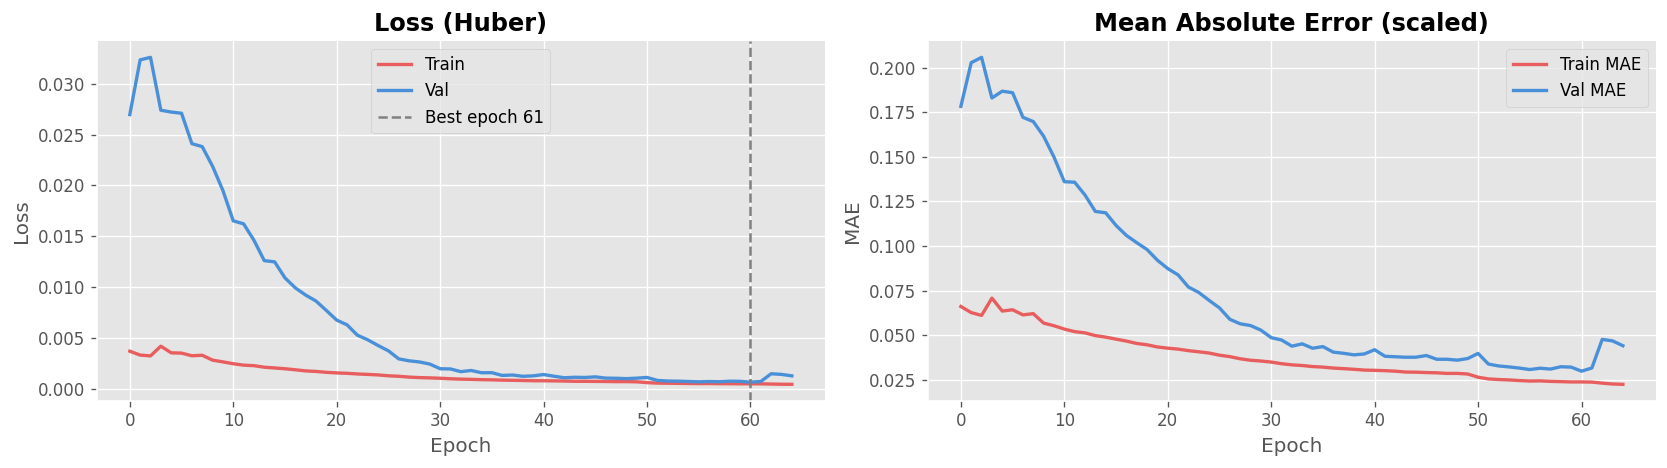

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history["loss"],     label="Train", color="#E85D5D", lw=2)
axes[0].plot(history.history["val_loss"], label="Val",   color="#4A90D9", lw=2)
axes[0].axvline(best_epoch - 1, color="gray", linestyle="--", label=f"Best epoch {best_epoch}")
axes[0].set_title("Loss (Huber)", fontweight="bold")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history.history["mae"],     label="Train MAE", color="#E85D5D", lw=2)
axes[1].plot(history.history["val_mae"], label="Val MAE",   color="#4A90D9", lw=2)
axes[1].set_title("Mean Absolute Error (scaled)", fontweight="bold")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("MAE")
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{MODEL_IMAGES_DIR}/training_curves.png", bbox_inches="tight")
plt.show()

## 8. Evaluation & Visualization

In [68]:
y_pred_scaled = model.predict(X_test, verbose=0)
y_true_all    = np.array([inverse_temp(y_test[i])        for i in range(len(y_test))])
y_pred_all    = np.array([inverse_temp(y_pred_scaled[i]) for i in range(len(y_pred_scaled))])

mae  = mean_absolute_error(y_true_all.flatten(), y_pred_all.flatten())
rmse = np.sqrt(mean_squared_error(y_true_all.flatten(), y_pred_all.flatten()))
r2   = r2_score(y_true_all.flatten(), y_pred_all.flatten())

print("═" * 45)
print("  TEST SET RESULTS")
print("═" * 45)
print(f"  MAE  : {mae:.4f} °C")
print(f"  RMSE : {rmse:.4f} °C")
print(f"  R²   : {r2:.4f}")
print("═" * 45)

print(f"\n{'Step':>6} {'MAE':>8} {'RMSE':>8} {'R²':>8}")
print("─" * 35)
per_step = {}
for step in range(FORECAST_N):
    s_mae  = mean_absolute_error(y_true_all[:, step], y_pred_all[:, step])
    s_rmse = np.sqrt(mean_squared_error(y_true_all[:, step], y_pred_all[:, step]))
    s_r2   = r2_score(y_true_all[:, step], y_pred_all[:, step])
    per_step[f"+{step+1}h"] = {"mae": round(s_mae, 4), "rmse": round(s_rmse, 4), "r2": round(s_r2, 4)}
    print(f"{f'+{step+1}h':>6} {s_mae:>8.4f} {s_rmse:>8.4f} {s_r2:>8.4f}")

═════════════════════════════════════════════
  TEST SET RESULTS
═════════════════════════════════════════════
  MAE  : 1.2369 °C
  RMSE : 1.4642 °C
  R²   : 0.9507
═════════════════════════════════════════════

  Step      MAE     RMSE       R²
───────────────────────────────────
   +1h   1.0973   1.2863   0.9618
   +2h   1.1611   1.3675   0.9569
   +3h   1.2356   1.4582   0.9511
   +4h   1.3334   1.5741   0.9431
   +5h   1.3572   1.6095   0.9405


In [74]:
per_step

{'+1h': {'mae': 1.0973, 'rmse': 1.2863, 'r2': 0.9618},
 '+2h': {'mae': 1.1611, 'rmse': 1.3675, 'r2': 0.9569},
 '+3h': {'mae': 1.2356, 'rmse': 1.4582, 'r2': 0.9511},
 '+4h': {'mae': 1.3334, 'rmse': 1.5741, 'r2': 0.9431},
 '+5h': {'mae': 1.3572, 'rmse': 1.6095, 'r2': 0.9405}}

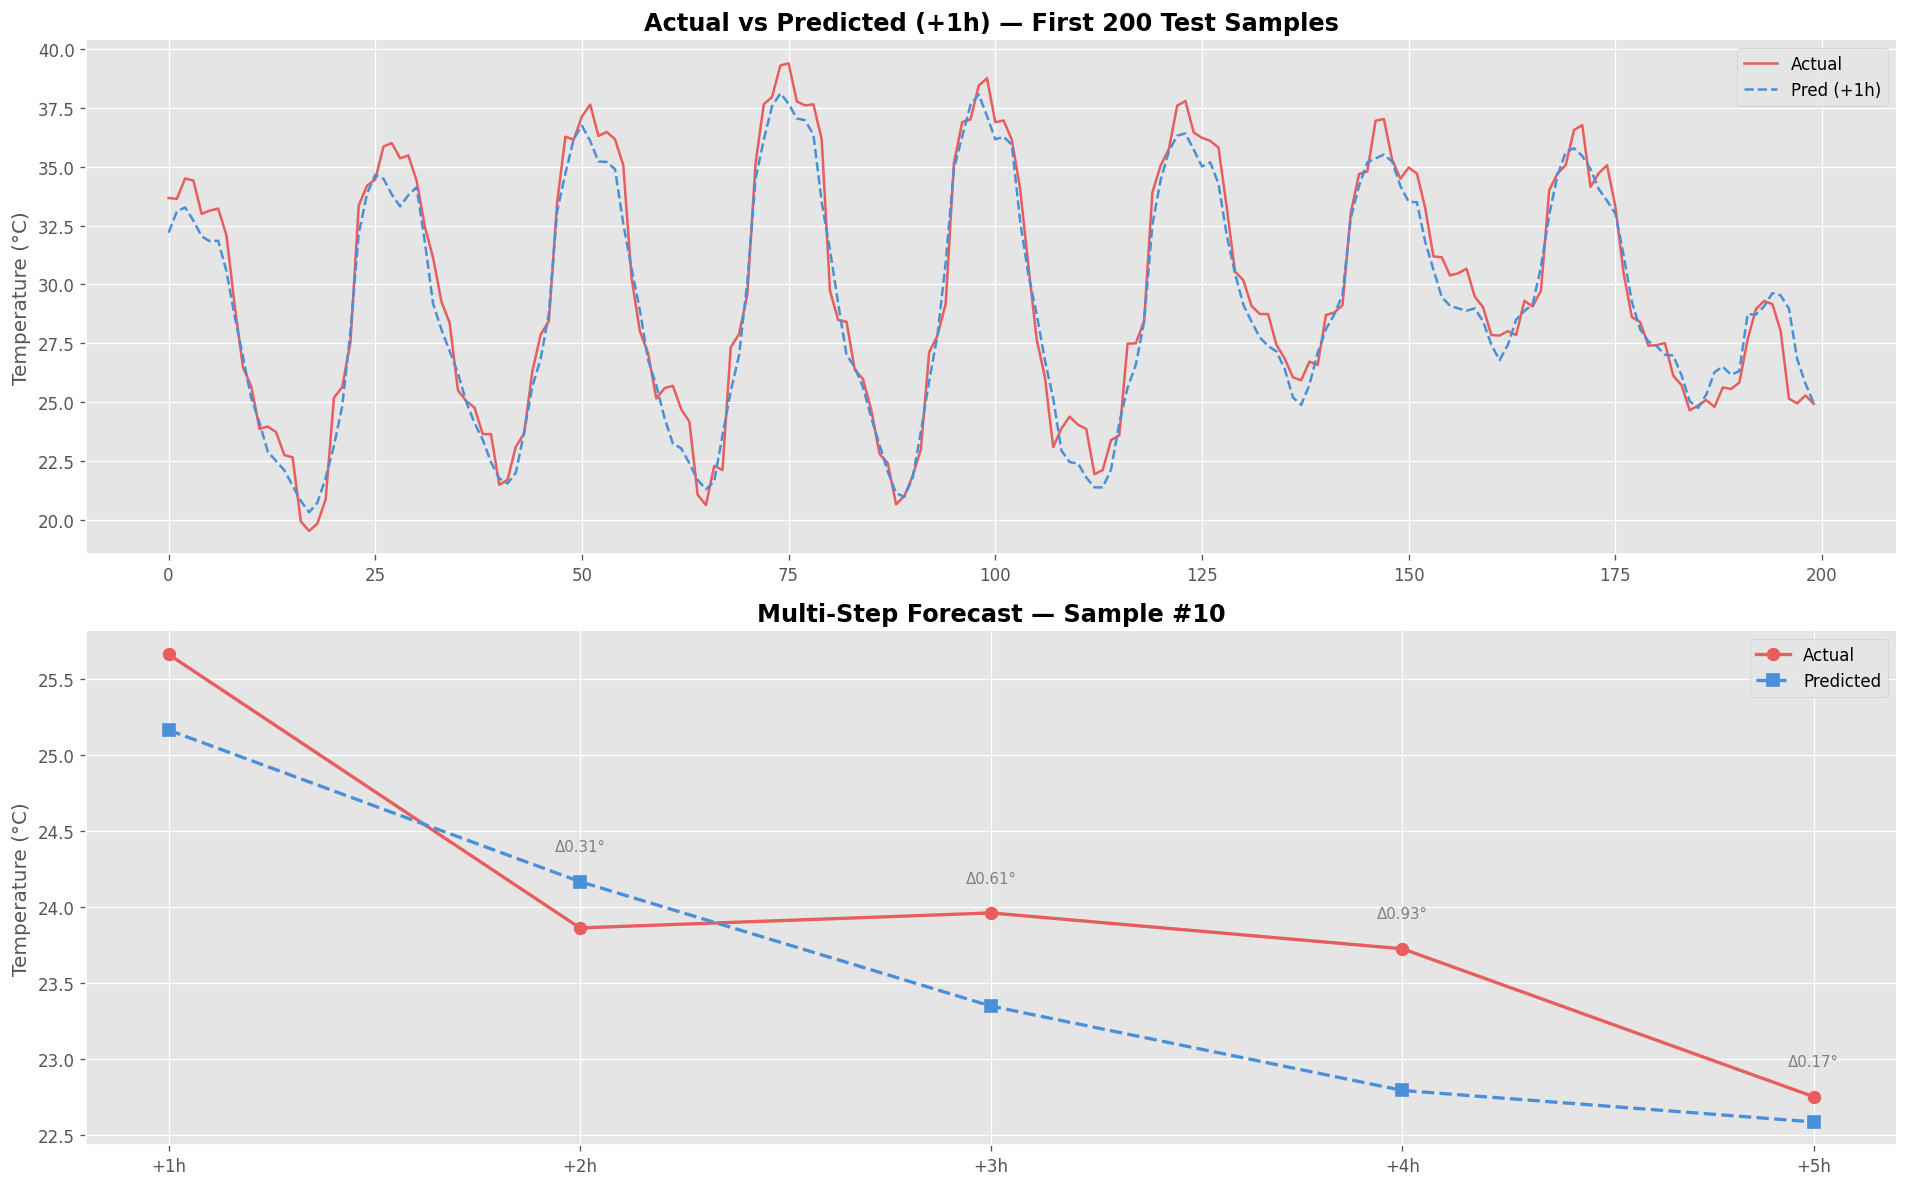

In [69]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

n_show = min(200, len(y_true_all))
axes[0].plot(range(n_show), y_true_all[:n_show, 0], label="Actual",       color="#E85D5D", lw=1.5)
axes[0].plot(range(n_show), y_pred_all[:n_show, 0], label="Pred (+1h)",   color="#4A90D9", lw=1.5, ls="--")
axes[0].set_title(f"Actual vs Predicted (+1h) — First {n_show} Test Samples", fontweight="bold")
axes[0].set_ylabel("Temperature (°C)"); axes[0].legend()

sample_idx    = 10
actual_sample = y_true_all[sample_idx]
pred_sample   = y_pred_all[sample_idx]
steps         = [f"+{i+1}h" for i in range(FORECAST_N)]
axes[1].plot(steps, actual_sample, "o-", label="Actual",    color="#E85D5D", lw=2, ms=7)
axes[1].plot(steps, pred_sample,   "s--", label="Predicted", color="#4A90D9", lw=2, ms=7)
for i, (a, p) in enumerate(zip(actual_sample, pred_sample)):
    axes[1].annotate(f"Δ{abs(a-p):.2f}°", (steps[i], max(a,p)+0.2), ha="center", fontsize=9, color="gray")
axes[1].set_title(f"Multi-Step Forecast — Sample #{sample_idx}", fontweight="bold")
axes[1].set_ylabel("Temperature (°C)"); axes[1].legend()

plt.tight_layout()
plt.savefig(f"{MODEL_IMAGES_DIR}/predictions.png", bbox_inches="tight")
plt.show()

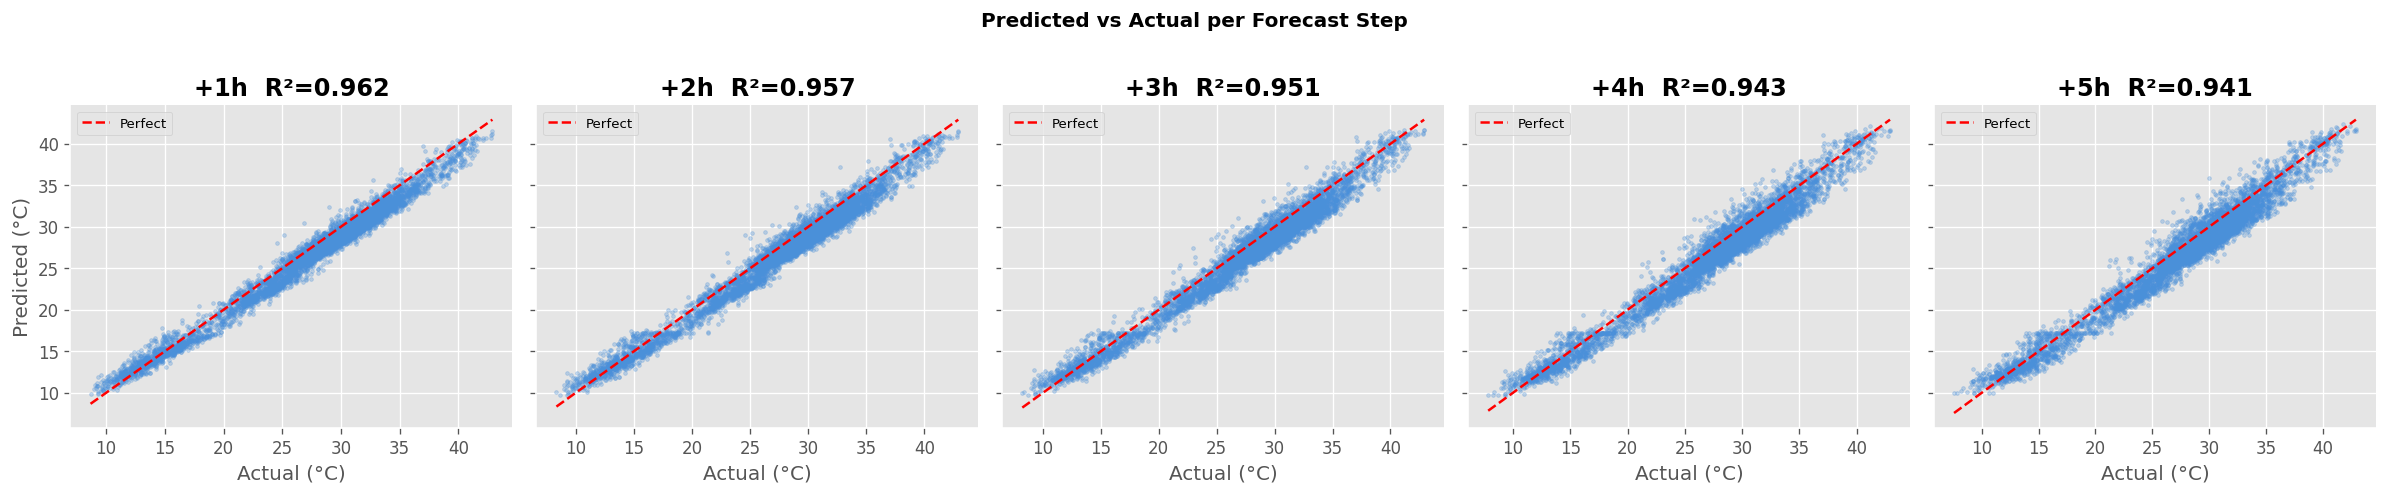

In [70]:
fig, axes = plt.subplots(1, FORECAST_N, figsize=(4*FORECAST_N, 4), sharey=True)
if FORECAST_N == 1: axes = [axes]

for step, ax in enumerate(axes):
    ax.scatter(y_true_all[:, step], y_pred_all[:, step], alpha=0.3, s=5, color="#4A90D9")
    lims = [min(y_true_all[:,step].min(), y_pred_all[:,step].min()),
            max(y_true_all[:,step].max(), y_pred_all[:,step].max())]
    ax.plot(lims, lims, "r--", lw=1.5, label="Perfect")
    s_r2 = r2_score(y_true_all[:, step], y_pred_all[:, step])
    ax.set_title(f"+{step+1}h  R²={s_r2:.3f}", fontweight="bold")
    ax.set_xlabel("Actual (°C)")
    if step == 0: ax.set_ylabel("Predicted (°C)")
    ax.legend(fontsize=8)

plt.suptitle("Predicted vs Actual per Forecast Step", fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{MODEL_IMAGES_DIR}/scatter_per_step.png", bbox_inches="tight")
plt.show()

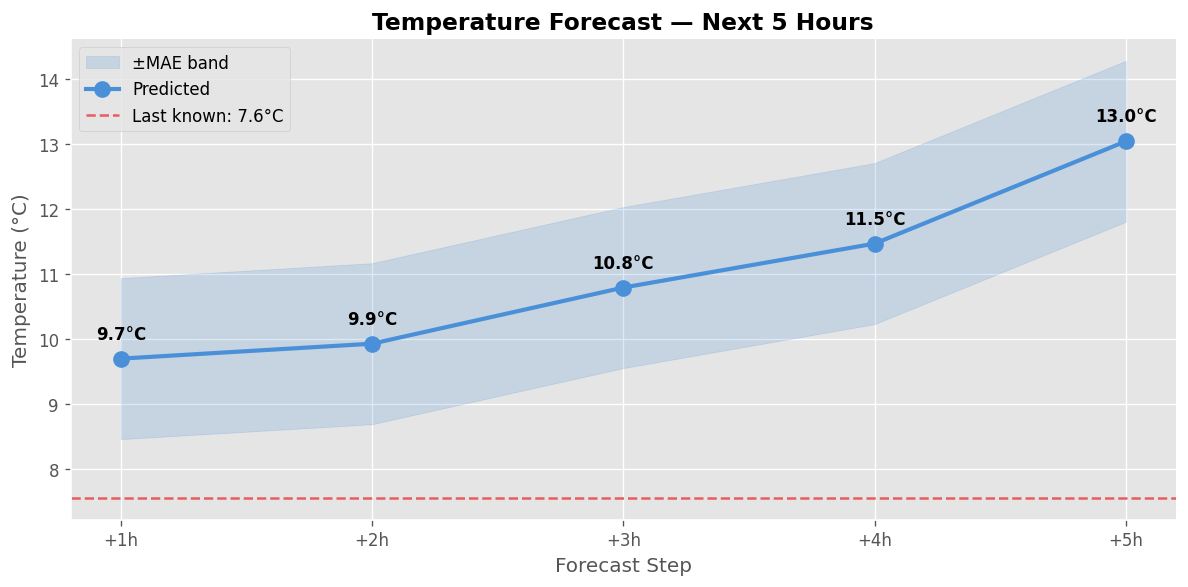

In [71]:
# Live forecast demo with confidence band
recent_window = df_model.tail(LOOKBACK + 5)
window_scaled = scaler.transform(recent_window[FEATURES].iloc[-LOOKBACK:].values).reshape(1, LOOKBACK, N_FEATURES)
pred_scaled   = model.predict(window_scaled, verbose=0)[0]
pred_temps    = inverse_temp(pred_scaled)

hours = [f"+{i+1}h" for i in range(FORECAST_N)]

fig, ax = plt.subplots(figsize=(10, 5))
ax.fill_between(hours, pred_temps - mae, pred_temps + mae, alpha=0.2, color="#4A90D9", label="±MAE band")
ax.plot(hours, pred_temps, "o-", color="#4A90D9", lw=2.5, ms=9, label="Predicted")
for h, t in zip(hours, pred_temps):
    ax.annotate(f"{t:.1f}°C", (h, t), textcoords="offset points", xytext=(0, 12),
                ha="center", fontsize=10, fontweight="bold")
last_actual = df_model[TARGET_COL].iloc[-1]
ax.axhline(last_actual, color="#E85D5D", linestyle="--", lw=1.5, label=f"Last known: {last_actual:.1f}°C")
ax.set_title(f"Temperature Forecast — Next {FORECAST_N} Hours", fontsize=14, fontweight="bold")
ax.set_ylabel("Temperature (°C)"); ax.set_xlabel("Forecast Step")
ax.legend()
plt.tight_layout()
plt.savefig(f"{MODEL_IMAGES_DIR}/forecast_plot.png", bbox_inches="tight")
plt.show()

## 9. Save Model & Log to MLflow

In [72]:
model_path = f"{MODEL_DIR}/lstm_temp_model.keras"
meta_path  = f"{MODEL_DIR}/model_meta.json"

model.save(model_path)

meta = {
    "model"         : "Encoder-Decoder BiLSTM",
    "target"        : TARGET_COL,
    "features"      : FEATURES,
    "target_idx"    : TARGET_IDX,
    "lookback"      : LOOKBACK,
    "forecast_n"    : FORECAST_N,
    "n_features"    : N_FEATURES,
    "hyperparameters": {
        "lstm_units"   : LSTM_UNITS,
        "dropout_rate" : DROPOUT_RATE,
        "learning_rate": LEARNING_RATE,
        "batch_size"   : BATCH_SIZE,
    },
    "best_epoch"    : best_epoch,
    "best_val_loss" : round(best_val_loss, 6),
    "train_samples" : int(len(X_train)),
    "val_samples"   : int(len(X_val)),
    "test_samples"  : int(len(X_test)),
    "metrics": {
        "mae_celsius"  : round(float(mae),  4),
        "rmse_celsius" : round(float(rmse), 4),
        "r2_score"     : round(float(r2),   4),
    },
    "per_step_metrics": per_step,
    "scaler_path"   : scaler_path,
}

with open(meta_path, "w") as f:
    json.dump(meta, f, indent=2)

print(f"Model saved → {model_path}")
print(f"Meta  saved → {meta_path}")

Model saved → ../models/lstm/lstm_temp_model.keras
Meta  saved → ../models/lstm/model_meta.json


In [75]:
with mlflow.start_run(run_name="lstm_temperature_final") as run:
    mlflow.set_tags({
        "model_type" : "BiLSTM Encoder-Decoder",
        "task"       : "temperature_forecasting",
        "dataset"    : "ERA5_Azamgarh",
        "stage"      : "final",
        "optuna_run" : optuna_run_id,
    })

    mlflow.log_params({
        "lstm_units"   : LSTM_UNITS,
        "dropout_rate" : DROPOUT_RATE,
        "learning_rate": LEARNING_RATE,
        "batch_size"   : BATCH_SIZE,
        "lookback"     : LOOKBACK,
        "forecast_n"   : FORECAST_N,
        "n_features"   : N_FEATURES,
    })

    mlflow.log_metrics({
        "mae_celsius"  : round(float(mae),        4),
        "rmse_celsius" : round(float(rmse),       4),
        "r2_score"     : round(float(r2),         4),
        "best_epoch"   : best_epoch,
        "best_val_loss": round(best_val_loss,     6),
    })

    for step_name, step_metrics in per_step.items():
        clean = step_name.replace("+", "plus_").replace("h", "hr")  # +1h → plus_1hr
        mlflow.log_metric(f"mae_{clean}",  step_metrics["mae"])
        mlflow.log_metric(f"rmse_{clean}", step_metrics["rmse"])
        mlflow.log_metric(f"r2_{clean}",   step_metrics["r2"])
    
    for artifact in [
        model_path, meta_path, scaler_path,
        f"{MODEL_IMAGES_DIR}/training_curves.png",
        f"{MODEL_IMAGES_DIR}/predictions.png",
        f"{MODEL_IMAGES_DIR}/scatter_per_step.png",
        f"{MODEL_IMAGES_DIR}/forecast_plot.png",
        f"{MODEL_IMAGES_DIR}/autocorrelation.png",
        f"{MODEL_IMAGES_DIR}/optuna_results.png",
    ]:
        try:
            mlflow.log_artifact(artifact)
        except Exception:
            pass

    mlflow.keras.log_model(model, "lstm_model")
    final_run_id = run.info.run_id

print(f"Final run logged → {final_run_id}")
print(f"View at → {MLFLOW_TRACKING_URI}/#/experiments")

2026/10/10 19:43:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/10/10 19:43:22 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


🏃 View run lstm_temperature_final at: https://dagshub.com/Sharif-Abusad/weather-forecasting-system-mlops.mlflow/#/experiments/1/runs/cf7e3e5b06784c9da09bfa1b16bf55ad
🧪 View experiment at: https://dagshub.com/Sharif-Abusad/weather-forecasting-system-mlops.mlflow/#/experiments/1
Final run logged → cf7e3e5b06784c9da09bfa1b16bf55ad
View at → https://dagshub.com/Sharif-Abusad/weather-forecasting-system-mlops.mlflow/#/experiments


## 10. Inference Function

In [76]:
# Reload fresh (simulates app startup)
loaded_model  = load_model(model_path, safe_mode=False)
loaded_scaler = joblib.load(scaler_path)
with open(meta_path) as f:
    loaded_meta = json.load(f)

print(f"Model reloaded — FORECAST_N={loaded_meta['forecast_n']} | MAE=±{loaded_meta['metrics']['mae_celsius']}°C")


def predict_temperature(recent_df: pd.DataFrame, n_hours: int = FORECAST_N) -> dict:
    _meta     = loaded_meta
    _model    = loaded_model
    _scaler   = loaded_scaler
    _lookback = _meta["lookback"]
    _fn       = _meta["forecast_n"]
    _feats    = _meta["features"]
    _tidx     = _meta["target_idx"]
    _nfeat    = _meta["n_features"]

    n = n_hours if n_hours else _fn
    assert n <= _fn,         f"n_hours={n} exceeds trained forecast_n={_fn}"
    assert len(recent_df) >= _lookback, f"Need {_lookback} rows, got {len(recent_df)}"

    window        = recent_df[_feats].iloc[-_lookback:].values
    window_scaled = _scaler.transform(window).reshape(1, _lookback, _nfeat)
    pred_scaled   = _model.predict(window_scaled, verbose=0)[0][:n]

    dummy = np.zeros((n, _nfeat))
    dummy[:, _tidx] = pred_scaled
    pred_temps = _scaler.inverse_transform(dummy)[:, _tidx]

    return {
        "forecast"   : [{"hour": f"+{i+1}h", "temperature_C": round(float(t), 2)}
                        for i, t in enumerate(pred_temps)],
        "n_hours"    : n,
        "model"      : _meta["model"],
        "mae_celsius": _meta["metrics"]["mae_celsius"],
    }


result = predict_temperature(df_model.tail(LOOKBACK + 5))
print(f"\nTemperature Forecast (next {result['n_hours']} hours):")
print(f"{'Hour':<8} {'Temperature':>14}")
print("─" * 25)
for item in result["forecast"]:
    print(f"{item['hour']:<8} {item['temperature_C']:>12.2f} °C")
print(f"\nModel MAE: ±{result['mae_celsius']} °C")

Model reloaded — FORECAST_N=5 | MAE=±1.2369°C

Temperature Forecast (next 5 hours):
Hour        Temperature
─────────────────────────
+1h              9.70 °C
+2h              9.93 °C
+3h             10.79 °C
+4h             11.47 °C
+5h             13.04 °C

Model MAE: ±1.2369 °C


In [77]:
print("\n" + "═"*55)
print("  EXPERIMENT COMPLETE — SUMMARY")
print("═"*55)
print(f"  Architecture  : Encoder-Decoder BiLSTM")
print(f"  Input         : {LOOKBACK}h × {N_FEATURES} features")
print(f"  Output        : {FORECAST_N} hours of temperature")
print(f"  Optuna trials : {len(study.trials)}")
print(f"  Best val_loss : {study.best_value:.6f}")
print(f"  Test MAE      : {mae:.4f} °C")
print(f"  Test RMSE     : {rmse:.4f} °C")
print(f"  Test R²       : {r2:.4f}")
print(f"  MLflow run    : {final_run_id}")
print(f"  Model saved   → {model_path}")
print("═"*55)


═══════════════════════════════════════════════════════
  EXPERIMENT COMPLETE — SUMMARY
═══════════════════════════════════════════════════════
  Architecture  : Encoder-Decoder BiLSTM
  Input         : 24h × 12 features
  Output        : 5 hours of temperature
  Optuna trials : 20
  Best val_loss : 0.000578
  Test MAE      : 1.2369 °C
  Test RMSE     : 1.4642 °C
  Test R²       : 0.9507
  MLflow run    : cf7e3e5b06784c9da09bfa1b16bf55ad
  Model saved   → ../models/lstm/lstm_temp_model.keras
═══════════════════════════════════════════════════════
